# Installs

In [40]:
!pip install prophet
!pip install yfinance

# Imports

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader as web
import warnings
from prophet import Prophet
import yfinance as yf

# Link The Latest Dataset


In [42]:
google = yf.Ticker("GOOG")
data = google.history(start="2019-08-09")
data = data.reset_index()
data = data.rename(columns={"Date": "ds", "Close": "y"})
data["ds"] = data["ds"].dt.tz_localize(None)
data.head()

,ds,Open,High,Low,y,Volume,Dividends,Stock Splits
0,2019-08-09,59.376002,59.667927,58.662937,58.881363,21314000,0.0,0.0
1,2019-08-12,58.445200,58.730190,57.873341,58.222168,20060000,0.0,0.0
2,2019-08-13,58.061091,59.712527,58.061091,59.340309,25888000,0.0,0.0
3,2019-08-14,58.301472,58.598358,57.519865,57.705727,31574000,0.0,0.0
4,2019-08-15,57.666571,58.278180,57.597679,57.852928,24374000,0.0,0.0


# Visualizing The Data

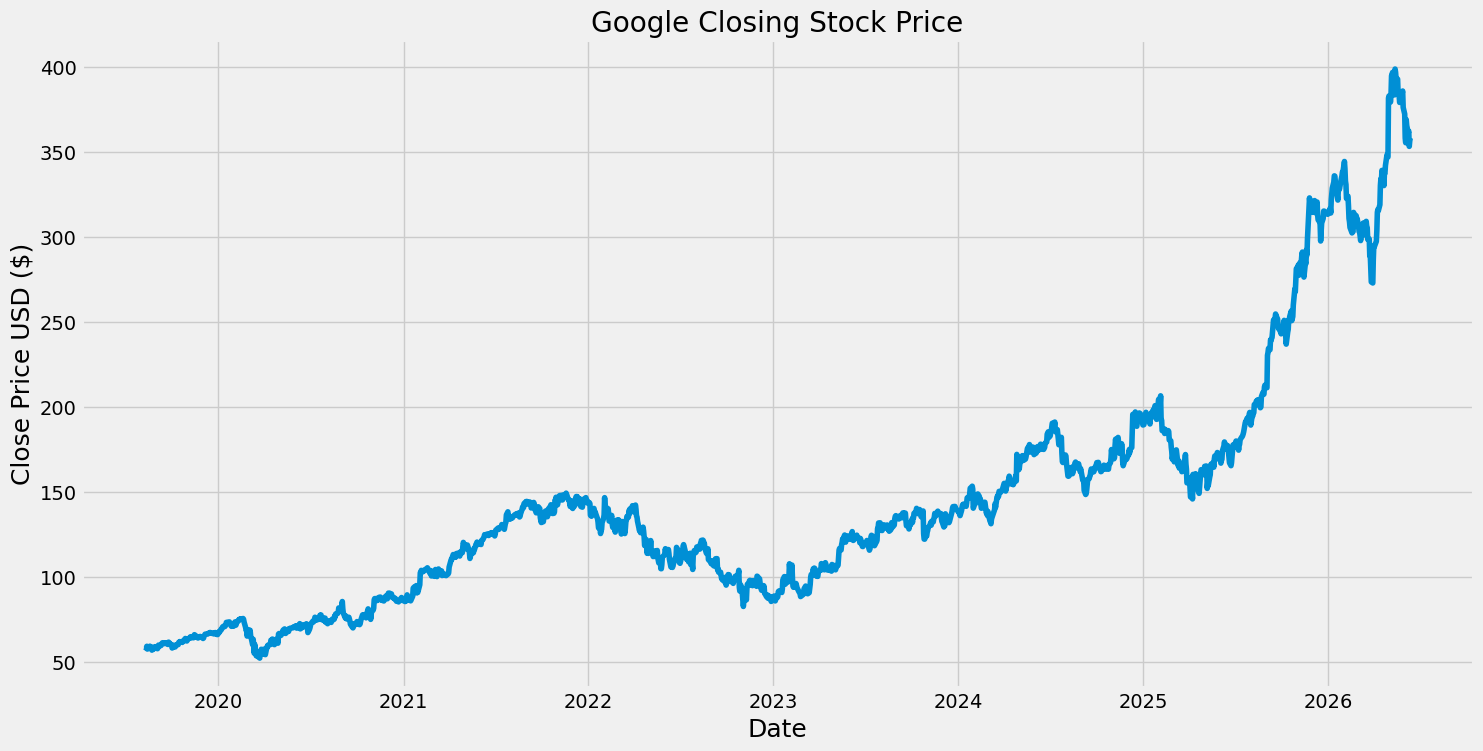

In [43]:
plt.style.use("fivethirtyeight")
plt.figure(figsize=(16,8))
plt.title("Google Closing Stock Price")
plt.plot(data["ds"], data["y"])
plt.xlabel("Date", fontsize=18)
plt.ylabel("Close Price USD ($)", fontsize=18)
plt.show()

# Isolating **Date** and **Close** Columns

In [44]:
data = data[["ds","y"]]
data.head()

,ds,y
0,2019-08-09,58.881363
1,2019-08-12,58.222168
2,2019-08-13,59.340309
3,2019-08-14,57.705727
4,2019-08-15,57.852928


# Fitting The Data to the **Facebook Prophet Model** for Stock Price Prediction

In [45]:
# you can set it to True if you want to include Hourly Prediction,
# but for this dataset, it would be inaccurate since it doesn't include hourly prices
m = Prophet(daily_seasonality=False)

m.fit(data)

# Looking at the **Stock Price Prediction** Made By The Trained Model

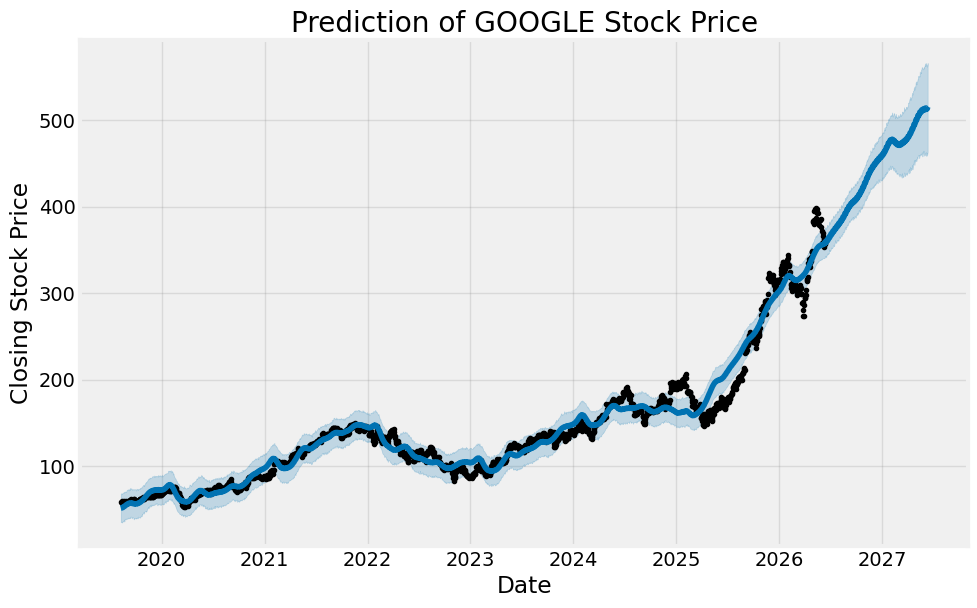

In [46]:
future = m.make_future_dataframe(periods=365)
predictions=m.predict(future)
m.plot(predictions)
plt.title("Prediction of GOOGLE Stock Price")
plt.xlabel("Date")
plt.ylabel("Closing Stock Price")
plt.show()

# Looking at the Seasonal Affects on that Prediction Made by the Trained Model

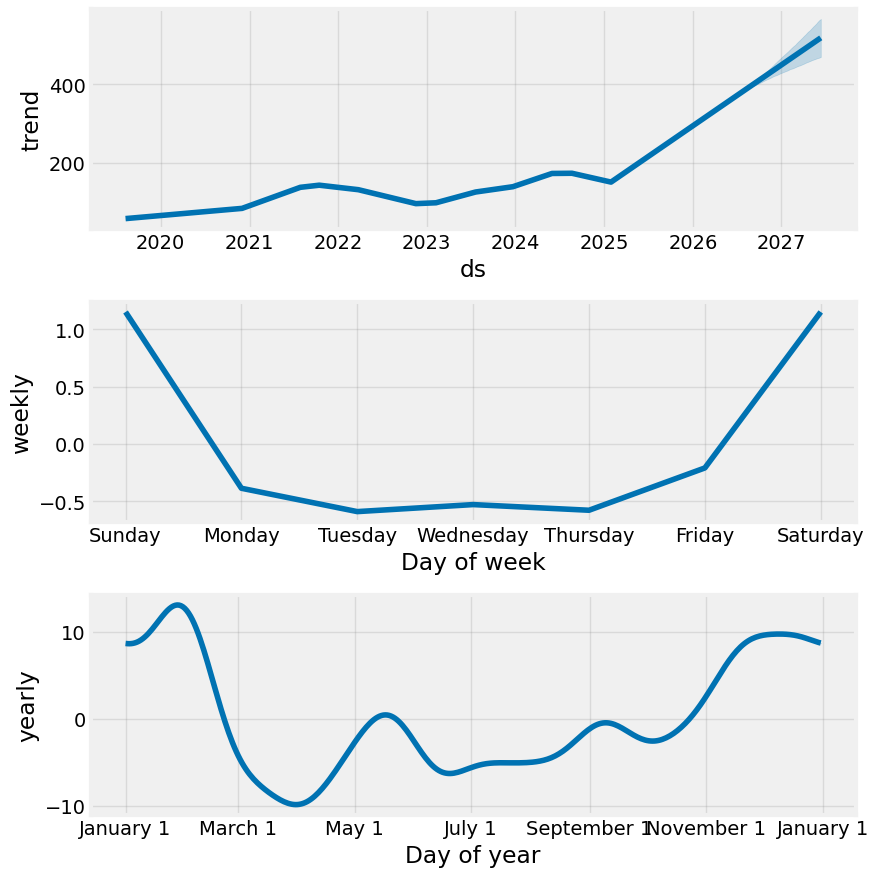

In [47]:
m.plot_components(predictions)
plt.show()